# Trajectories on Satellite Curtains
This notebook explores the plotting of trajectories KDEs intersecting a satellite groundtrack.


In [1]:
import sys
import os

sys.path.append(os.path.abspath('../gigatraj'))
%matplotlib inline

from datetime import datetime, timezone

import gigatraj  as pygt
import earthcare as ec
import sat_plane as sp
import traj_plot as tp


## Times of EarthCARE Orbits

### Times of EarthCARE Orbits

In [3]:
tle_directory = "./TLE"
t1, t2 = ec.get_frametimes(12908, "B", tle_directory)
print(t1, t2)

2026-09-05 12:31:09.757635+00:00 2026-09-05 12:42:56.433611+00:00


### EarthCARE Orbits at a given time

In [4]:
t = datetime(2026, 9, 3, 15, 50, tzinfo=timezone.utc)
orbit, frame = ec.get_frame(t,tle_directory)
print(orbit, frame)

12879 B


## Load Trajectories

In [5]:
gt = pygt.GIGATRAJ()
Trajs = gt.loadTrajectories()

2026-09-06 16:17:01.353317+00:00 2026-09-06 16:28:48.029293+00:00


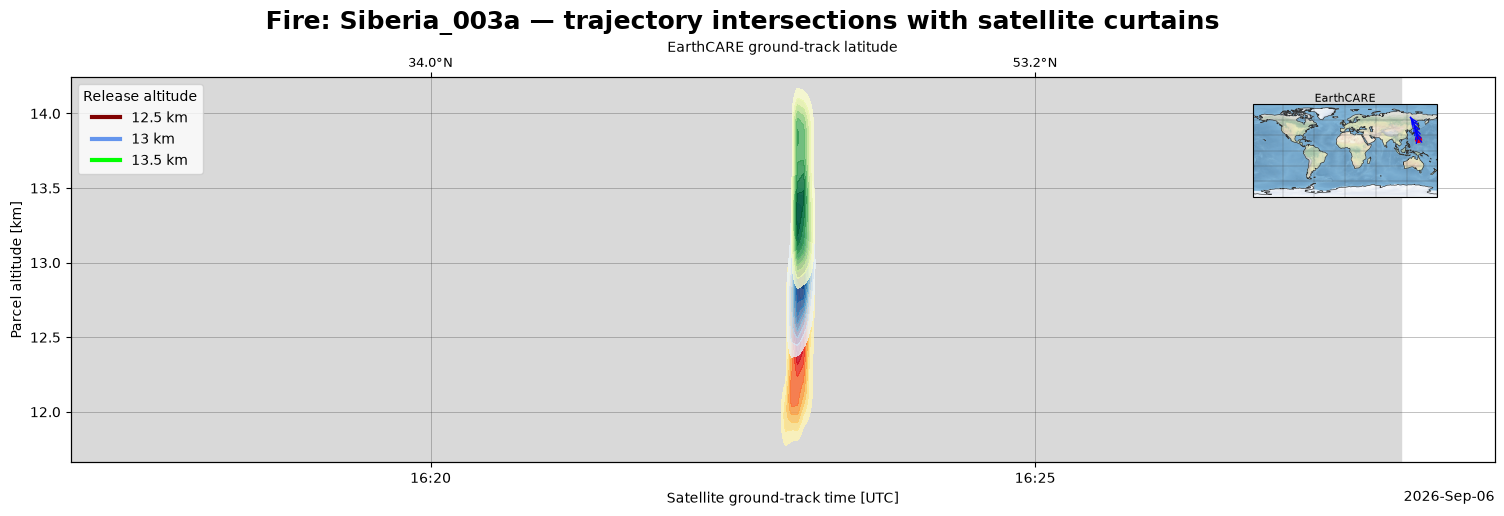

In [12]:
# Full orbit
satellites = [ 'EarthCARE',]
t1, t2 = ec.get_frametimes(12926, "B", tle_directory)
print(t1,t2)
figure, _ = sp.plot_satplane(Trajs[0], t1, t2, satellites,map_center='Pacific')

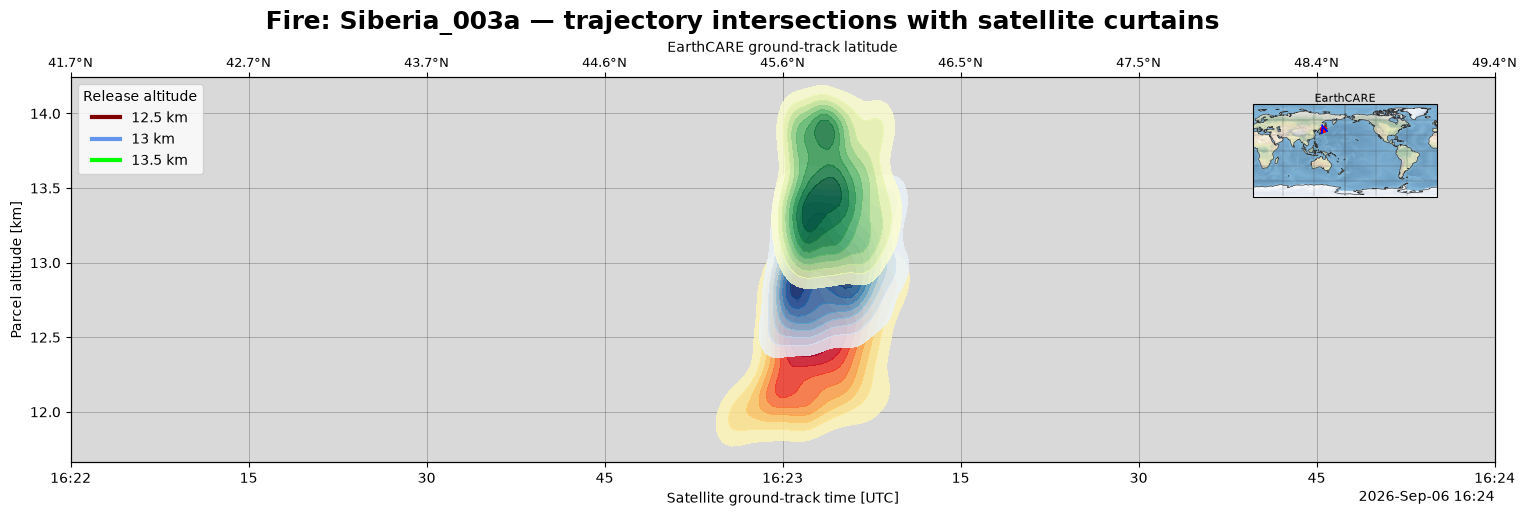

In [15]:
# Zoomed in
# ---------
t1 = datetime(2026,9,6,16,22)
t2 = datetime(2026,9,6,16,24)
figure, _ = sp.plot_satplane(Trajs[0], t1, t2, satellites, map_center='Pacific')

2026-09-07 13:52:40.962459+00:00 2026-09-07 14:04:27.609139+00:00


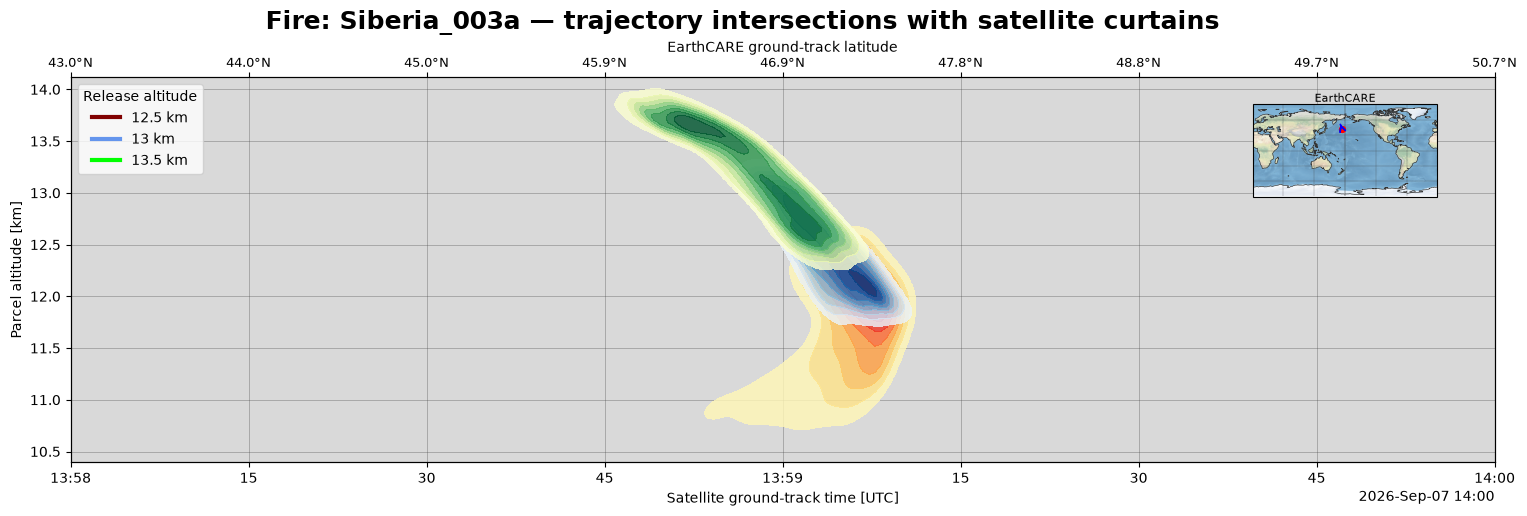

In [16]:
t1, t2 = ec.get_frametimes(12940, "B", tle_directory)
print(t1,t2)
t1 = datetime(2026,9,7,13,58)
t2 = datetime(2026,9,7,14,00)
figure, _ = sp.plot_satplane(Trajs[0], t1, t2, satellites, map_center='Pacific')

2026-09-07 12:20:08.320496+00:00 2026-09-07 12:31:54.937879+00:00


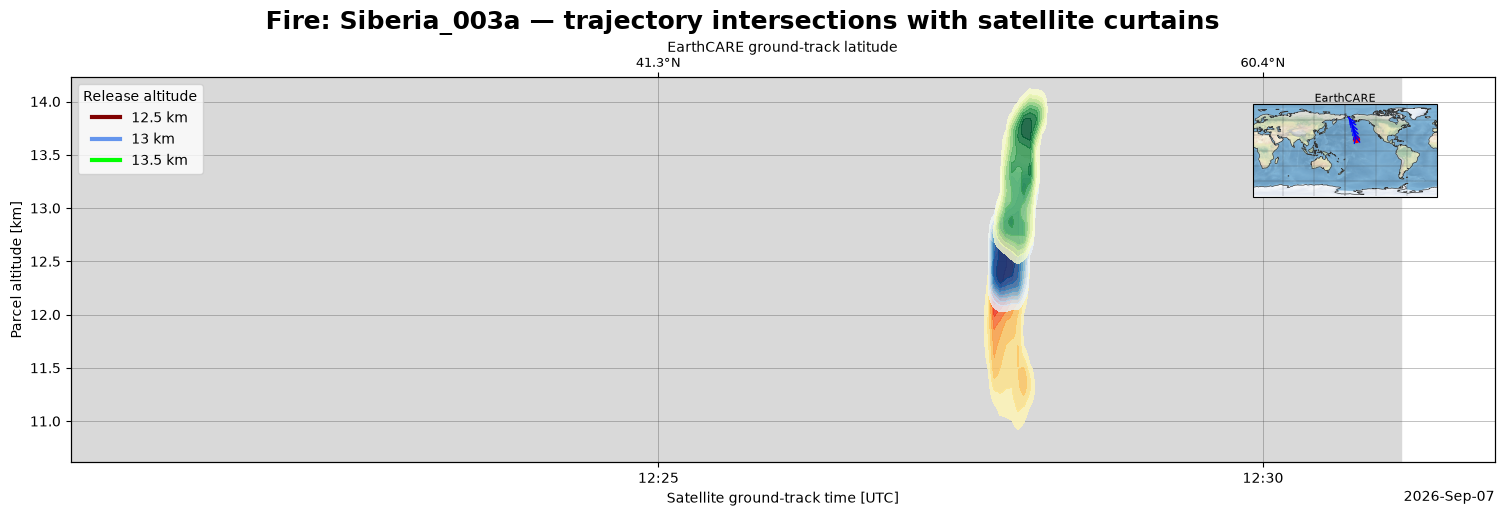

In [26]:
# Full orbit
satellites = [ 'EarthCARE',]
t1, t2 = ec.get_frametimes(12939, "B", tle_directory)
print(t1,t2)
figure, _ = sp.plot_satplane(Trajs[0], t1, t2, satellites,map_center='Pacific')

## IFS Plots

In [3]:
gt = pygt.GIGATRAJ()
gt.cf['Trajectories']['Catalog'] = 'MetIFS'
Trajs = gt.loadTrajectories()
display(Trajs[0][0])


<xarray.Dataset> Size: 5MB
Dimensions:    (time: 121, id: 2500)
Coordinates:
  * time       (time) datetime64[ns] 968B 2026-09-05T15:00:00 ... 2026-09-10T...
  * id         (id) float64 20kB 0.0 1.0 2.0 ... 2.497e+03 2.498e+03 2.499e+03
Data variables:
    lon        (time, id) float32 1MB ...
    lat        (time, id) float32 1MB ...
    P          (time, id) float32 1MB ...
    timestamp  (time) <U16 8kB ...
    PAlt       (time, id) float32 1MB ...
Attributes:
    Contents:              gigatraj trajectories
    Creation_date:         Sun Sep  6 19:21:43 2026  GMT
    Trajectory_start:      2026-09-05T15:00
    Trajectory_direction:  fwd
    altitude_km:           12
    fire:                  Siberia_003d
    catalog:               MetIFS

2026-09-07 12:20:08.320496+00:00 2026-09-07 12:31:54.937879+00:00


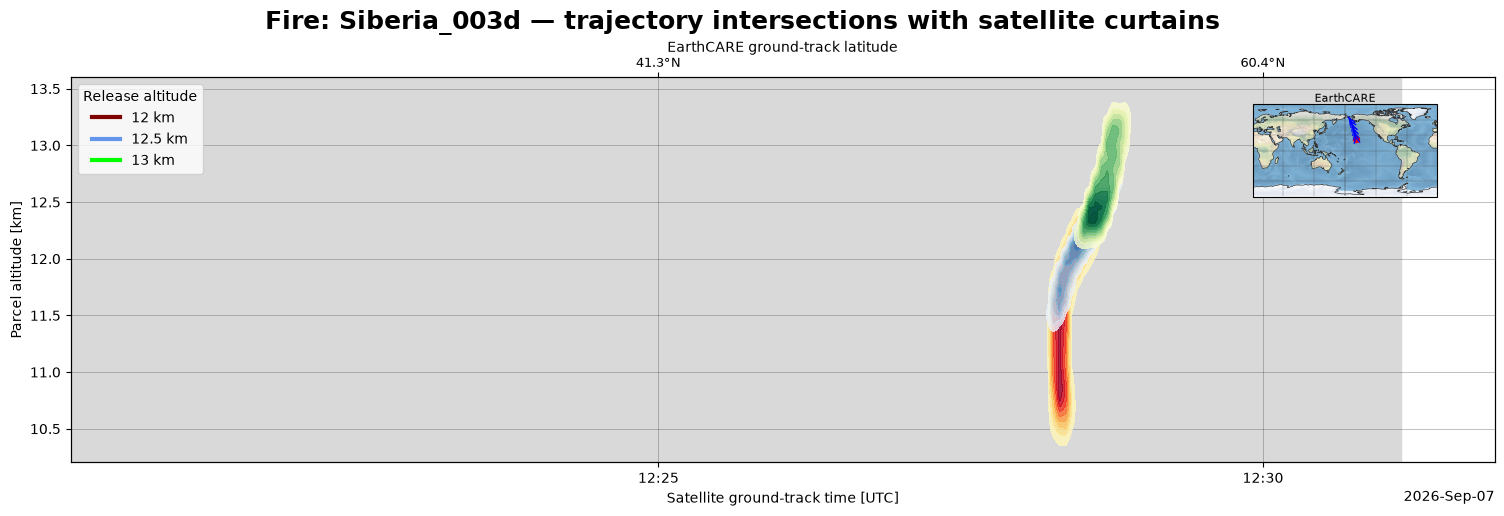

In [5]:
# Full orbit
satellites = [ 'EarthCARE',]
t1, t2 = ec.get_frametimes(12939, "B", tle_directory='./TLE')
print(t1,t2)
figure, _ = sp.plot_satplane(Trajs[0], t1, t2, satellites,map_center='Pacific')

## Merged datasets

In [2]:
gt = pygt.GIGATRAJ()
gt.cf['Trajectories']['Catalog'] = 'MetIFS'

Trajs = gt.loadTrajectories(merge_fires=True)
print(Trajs[0][0].attrs['fire'])
print(Trajs[0][1].attrs['fire'])
print(Trajs[0][2].attrs['fire'])

/shared/users-local/adasilva/swdev/AeroApps/src/Components/missions/INSPYRE/gigatraj/gigatraj.py:314: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.concat(list(_T[z].values()), dim="id")


Merged
Merged
Merged


2026-09-06 21:00:00


/shared/users-local/adasilva/conda/envs/inspyre/lib/python3.13/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


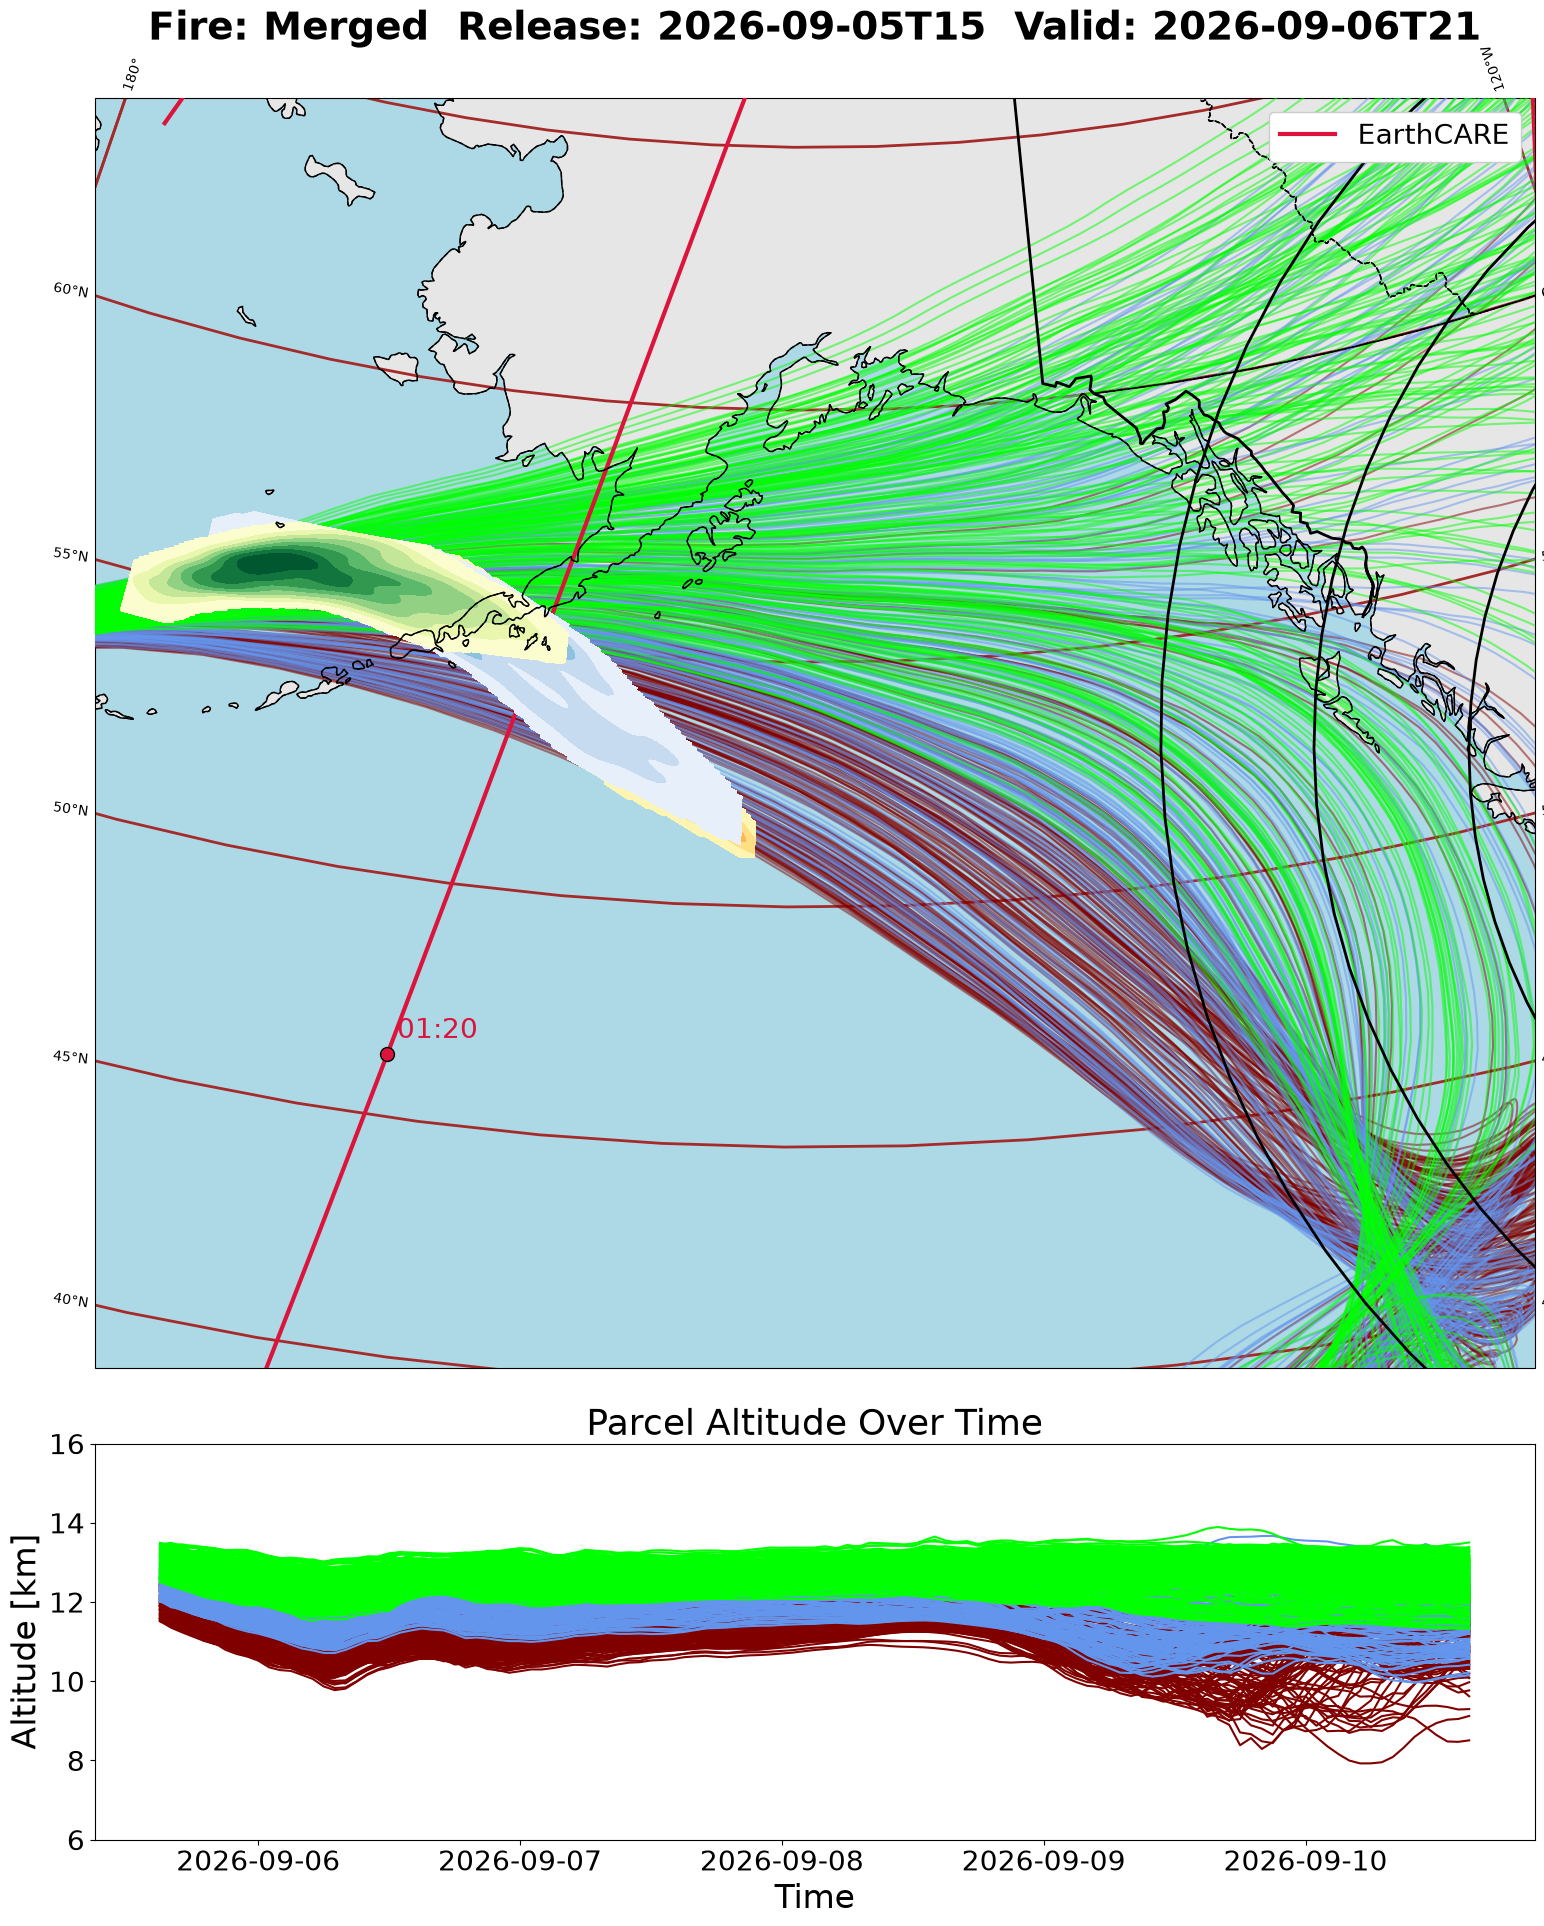

In [3]:
ValidTime = gt.cf['Plots']['Density_valid_time']
print(ValidTime)

fig, _ = tp.plot_traj (Trajs[0], ValidTime,
                       CampaignFile = '../gigatraj/inspyre.yaml',
                       satellites=['EarthCARE',],
                       geographic_bounds=pygt.MAP_REGION['alaska'])